In [8]:
import numpy as np 
import pandas as pd
from src import utils, redcells, db
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
from src.utils import Mouse
%matplotlib inline
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "D:/mouseobj/VGold_proc"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def get_retinotopy(mouse, RET_PATH):
    p = Path(RET_PATH).glob('**/*')
    n = "%s_%s" % (mouse.name, mouse.datexp)
    rtpy_file = [x for x in p if x.is_file() if n in x.name][0]
    #rtpy_file = Path(rtpy_file)
    print(f"Loading retinotopy data from {rtpy_file}")
    for file in np.load(rtpy_file, allow_pickle = True).files:
        exec(f"mouse.{file} = np.load(rtpy_file, allow_pickle = True)['{file}']")

from scipy.interpolate import interp1d

def stim_and_mic_time(dat,  spks, tlags = [3.5, 4.5], nplanes = 1):
    # spks is NN by NT
    # tlags at 30 Hz get summed up
    # dat contains the Timeline TL variable

    # this block extracts microscope frame times
    tdaq = dat['TL']['daq']['time']
    tdaq = np.array(tdaq)
    idaq = 80 * (1+np.arange(len(tdaq)))
    ddaq = dat['TL']['daq']['data'].T.flatten()
    ix = (ddaq[1:] < 2) * (ddaq[:-1]>2)
    imic = ix.nonzero()[0]
    imic = imic[:spks.shape[1]*nplanes:nplanes]
    tmic = np.interp(imic, idaq, tdaq)

    
    # the stimulus times and indices, 1-indexed
    istim = dat['TL']['stim']['istim']
    istim = istim.T.flatten()

    tstim = dat['TL']['stim']['time']
    istim = istim[:len(tstim)]#.astype('int32')

    # this interpolates and adds together frames at lag 3.5 and 4.5 from the stimulus
    f = interp1d(tmic, spks, fill_value = 'extrapolate')
    sp = f(tstim + tlags[0]/30 / (24 * 3600)) 
    for j in range(1, len(tlags)):
        sp += f(tstim + tlags[j]/30 / (24 * 3600))

    sp = sp.astype('float32')
    
    return sp, istim

import mat73
import os
def load_timeline(db):    
    mname, datexp, blk = db['mname'], db['datexp'], db['blk']
    root = os.path.join('Z:/data/PROC', mname, datexp, blk)
    fname     = 'Timeline_%s_%s_%s_RAW.mat'%(mname, datexp, blk) 
    fnamepath = os.path.join(root, fname) 
    data = mat73.loadmat(fnamepath)
    return data
        
def signal_variance(sstim, S):
    NN = S.shape[0]
    istim = np.unique(sstim)
    k = 0
    s2 = np.zeros((2, len(istim), NN), 'float32')
    
    for j in range(len(istim)):
        ix = np.nonzero(sstim == istim[j])[0]
        if len(ix) >= 2:
            s2[0, k] = S[:, ix[0]]
            # FIX: Reference S instead of s2
            s2[1, k] = S[:, ix[1]] 
            k += 1
            
    s2 = s2[:, :k]

    ss = s2 - np.mean(s2, 1)[:, np.newaxis, :]
    # FIX: Wrap denominator in parentheses
    ss = ss / (np.mean(ss**2, 1)[:, np.newaxis, :]**.5 + 1e-10) 

    csig = (ss[0] * ss[1]).mean(0)
    print('signal variance is %2.2f' % csig.mean())
    
    if csig.mean() < 0.05:
        print('The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.')

    return csig, ss

In [49]:
db_ = []
db_.append({'mname': 'VG56', 'datexp': '2026_07_13', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG58', 'datexp': '2026_07_14', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG59', 'datexp': '2026_07_14', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG63', 'datexp': '2026_08_12', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG64', 'datexp': '2026_08_12', 'blk':'2','stim':'8x4textures'})
db_.append({'mname': 'VG66', 'datexp': '2026_08_12', 'blk':'3','stim':'8x4textures'})
db_.append({'mname': 'VG69', 'datexp': '2026_08_12', 'blk':'4','stim':'8x4textures'})
db_.append({'mname': 'VG70', 'datexp': '2026_08_12', 'blk':'4','stim':'8x4textures'})

In [50]:
for iexp in range(3, len(db_)): #processing new mice
    name, datexp, blk, stim = db_[iexp]['mname'], db_[iexp]['datexp'], db_[iexp]['blk'], db_[iexp]['stim']
    print(f"Loading mouse {name} from {datexp} block {blk} stim {stim}")
    m = Mouse(name, datexp, blk, ROOT_PATH)
    m.load_neurons(dual_plane=True, return_iscell=True)
    get_retinotopy(m, RET_PATH)
    green_channel = Path(ROOT_PATH).joinpath(name, datexp, blk, "suite2p")
    m.isred = redcells.get_redcells(green_channel)
    condition = (m._is_cell[:,0].astype(bool)) #& (m._snr>=.25) removing the snr filter 
    m.isred = m.isred[condition]
    m._spks = m._spks[condition]
    m._xpos = m._xpos[condition]
    m._ypos = m._ypos[condition]
    m._iplane = m._iplane[condition]
    m.iarea = m.iarea[condition]
    m.iregion = m.iregion[condition]
    m.xy_t = m.xy_t[condition]
    dat_TL = load_timeline(db_[iexp])
    tlags = [10,11,12,13,14,15,17,18]
    csigs = []
    from scipy.stats import zscore
    for t in tlags:
        S, sstim = stim_and_mic_time(dat_TL, m._spks, nplanes = 1, tlags = [t]) 
        csig, ss = signal_variance(sstim, S)
        csigs.append(csig.mean())
    t = np.argmax(csigs) + tlags[0]
    print(f"Best lag is {t} frames, with mean signal variance {csigs[t - tlags[0]]:.4f}")
    neurons_atframes, m.subset_stim = stim_and_mic_time(dat_TL, m._spks, nplanes = 1, tlags = [t]) 
    m.neurons_atframes = zscore(neurons_atframes, axis = 1)
    csig, ss = signal_variance(m.subset_stim, m.neurons_atframes)
    m.csig = csig
    utils.save_mouse(m, compressed = False, mdl_path = MDL_PATH)

Loading mouse VG63 from 2026_08_12 block 2 stim 8x4textures
planes: 20


100%|██████████| 20/20 [00:48<00:00,  2.41s/it]


Loading retinotopy data from D:\retinotopy\aligned_xy\behav\VG63_2026_08_12_2_behav.npz
nrecording_rois: 20
(27934, 2)


ERROR:root:ERROR: MATLAB type not supported: internal.Serialport, (uint32)
ERROR:root:ERROR: MATLAB type not supported: icomm.mqtt.Client, (uint32)


signal variance is -0.00
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.00
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.01
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.02
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.02
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.03
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.03
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.04
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
Best la

...

signal variance is 0.03
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.06
signal variance is 0.08
signal variance is 0.10
signal variance is 0.12
signal variance is 0.13
signal variance is 0.15
signal variance is 0.15
Best lag is 17 frames, with mean signal variance 0.1507
signal variance is 0.15
Creating directory D:\mouseobj\VGold_proc\VG69\2026_08_12\4
Mouse object saved to D:\mouseobj\VGold_proc\VG69\2026_08_12\4
Loading mouse VG70 from 2026_08_12 block 4 stim 8x4textures
planes: 20


100%|██████████| 20/20 [00:34<00:00,  1.73s/it]


Loading retinotopy data from D:\retinotopy\aligned_xy\behav\VG70_2026_08_12_4_behav.npz
nrecording_rois: 20
(14540, 2)


ERROR:root:ERROR: MATLAB type not supported: internal.Serialport, (uint32)
ERROR:root:ERROR: MATLAB type not supported: icomm.mqtt.Client, (uint32)


signal variance is 0.03
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.05
The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.
signal variance is 0.07
signal variance is 0.09
signal variance is 0.11
signal variance is 0.12
signal variance is 0.14
signal variance is 0.14
Best lag is 17 frames, with mean signal variance 0.1423
signal variance is 0.14
Creating directory D:\mouseobj\VGold_proc\VG70\2026_08_12\4
Mouse object saved to D:\mouseobj\VGold_proc\VG70\2026_08_12\4


Invariance:

In [51]:
from src import invariance
def get_pair_invariance_df(mtx: np.array):
    cat = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved'] 
    areas = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    ctype = ['exc', 'inh'] 
    df_pair = pd.DataFrame()
    for m in range(mtx.shape[0]):
        for i_a, area in enumerate(areas):
            for ic, c in enumerate(ctype):
                df = pd.DataFrame()
                matrix = mtx[m, i_a, ic, :, :]
                condensed = invariance.condense_matrix(matrix, 8, 4)
                a, b = np.triu_indices(8,1)
                positive_cat = []
                negative_cat = []
                invariance_index = []
                for i in zip(a,b):
                    positive_cat.append(cat[i[0]])
                    negative_cat.append(cat[i[1]])
                    invariance_index.append(np.mean([condensed[i[0],i[0]], condensed[i[1],i[1]]]) - condensed[i[0],i[1]])
                df["positive_category"] = np.array(positive_cat)
                df["negative_category"] = np.array(negative_cat)
                df["pair_invariance"] = np.array(invariance_index)
                df["area"] = area
                df["ctype"] = c
                df["mouse"] = m  
                df_pair = pd.concat([df_pair, df])
    df_pair.reset_index(inplace=True, drop=True)
    return df_pair


def significance(pval):
    if  (pval >= .05) or (np.isnan(pval)):
        sig = ''
    elif (pval < .05) and (pval >= .01):
        sig = '*'
    elif (pval < .01) and (pval >= .001):
        sig = '**'
    else:
        sig = '***'
    return sig

from scipy.stats import ttest_rel
def plot_invariance_by_area_layer(df, ax):
    sns.pointplot(x="area", y="pair_invariance", hue="layer", data=df, 
              errorbar="se", linestyle='none', dodge=0.3, markers='o', palette=["#BA9E98", '#2D1E3E'],
              markersize=3, err_kws={'linewidth': 1.5}, legend=False, ax=ax)
    sns.despine()
    ax.set_ylabel("Invariance index")
    set_y = .45
    ax.set_ylim(0, .43)
    # lines 
    coordinates = [.5, 4.5, 6.5]
    for coord in coordinates:
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)

    #top text 
    corrdinates = [0, 2.5, 5.5, 8]
    texts = ['V1', 'Medial', 'Anterior', 'Lateral']
    colors = ["#66CCEE", "#AA3377", "#CCBB44", "#EE6677"]
    for i, coord in enumerate(corrdinates):
        ax.text(coord, set_y+.02, texts[i], ha='center', va='bottom', color=colors[i], fontsize=12)
    ax.set_xlabel("")
    # lines 

    ## Stats
    areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    for i, area in enumerate(areas_names):
        l1 = df.query(f"area == '{area}' and layer == 1").sort_values("mouse", ascending=True).pair_invariance.values
        l2 = df.query(f"area == '{area}' and layer == 2").sort_values("mouse", ascending=True).pair_invariance.values
        p_text = significance(ttest_rel(l1, l2, nan_policy='omit')[1])
        print(f"{area}: p-value = {ttest_rel(l1, l2, nan_policy='omit')[1]}")
        ax.text(i, set_y, f"{p_text}", ha='center', va='top', fontsize=10)
    tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
    labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
    for tlabel, tcolor in zip(ax.get_xticklabels(), tcolors):
        tlabel.set_color(tcolor)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels_)
    ax.xaxis.set_tick_params()
    ax.text(0.21, 0.17, "Layer 2", color="#BA9E98", rotation=0, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.21, 0.10, "Layer 3", color="#2D1E3E", rotation=0, ha='center', va='center', transform=ax.transAxes)

def plot_invariance_by_area_type(df, ax):
    sns.pointplot(x="area", y="pair_invariance", hue="ctype", data=df, 
              errorbar="se", linestyle='none', dodge=0.3, markers='o', palette=["#BA9E98", '#2D1E3E'],
              markersize=3, err_kws={'linewidth': 1.5}, legend=False, ax=ax)
    sns.despine()
    ax.set_ylabel("Invariance index")
    set_y = .45
    ax.set_ylim(0, .43)
    # lines 
    coordinates = [.5, 4.5, 6.5]
    for coord in coordinates:
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
        ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)

    #top text 
    corrdinates = [0, 2.5, 5.5, 8]
    texts = ['V1', 'Medial', 'Anterior', 'Lateral']
    colors = ["#66CCEE", "#AA3377", "#CCBB44", "#EE6677"]
    for i, coord in enumerate(corrdinates):
        ax.text(coord, set_y+.02, texts[i], ha='center', va='bottom', color=colors[i], fontsize=12)
    ax.set_xlabel("")
    # lines 

    ## Stats
    areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    for i, area in enumerate(areas_names):
        l1 = df.query(f"area == '{area}' and ctype == 'exc'").sort_values("mouse", ascending=True).pair_invariance.values
        l2 = df.query(f"area == '{area}' and ctype == 'inh'").sort_values("mouse", ascending=True).pair_invariance.values
        p_text = significance(ttest_rel(l1, l2, nan_policy='omit')[1])
        print(f"{area}: p-value = {ttest_rel(l1, l2, nan_policy='omit')[1]}")
        ax.text(i, set_y, f"{p_text}", ha='center', va='top', fontsize=10)
    tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
    labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
    for tlabel, tcolor in zip(ax.get_xticklabels(), tcolors):
        tlabel.set_color(tcolor)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels_)
    ax.xaxis.set_tick_params()
    ax.text(0.21, 0.17, "exc", color="#BA9E98", rotation=0, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.21, 0.10, "inh", color="#2D1E3E", rotation=0, ha='center', va='center', transform=ax.transAxes)

def plot_representations(ax, rep_mtx, area: int , layer:int, ctype: int, cbar=False, noylabels = False, noxlabels = False, labelsize=12, Title=None, ytext: tuple =None):
    #labels = create_labels_matrix()
    labels = ["leaves","circles","dryland","rocks","tiles","squares","rleaves","paved"]
    mask = np.eye(32, dtype=bool)
    # 4. Set the background color of the axes to black
    ax.set_facecolor('black')
    #sns.heatmap(rep_mtx[area,layer], cmap='RdBu_r', vmin=-1, vmax=1, center=0, xticklabels=labels, yticklabels=labels, ax=ax, cbar=cbar)
    if layer == -1:
        sns.heatmap(rep_mtx[area, ctype], cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax, mask=mask, rasterized=True, cbar=cbar)
    else:
        sns.heatmap(rep_mtx[area,layer,ctype], cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax, mask=mask, rasterized=True, cbar=cbar)
    ax.vlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
    ax.hlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
    if noylabels:
        ax.set_yticks([])
    else:
        ax.set_yticks(np.arange(2, 32, 4), labels, fontsize=labelsize, rotation=360)
        ax.tick_params(axis='y', pad=1, length=0)
    if noxlabels:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(2, 32, 4), labels, fontsize=labelsize, rotation=90)
        ax.tick_params(axis='x', pad=1, length=0)

    if Title is not None:
        ax.set_title(Title, fontweight='bold', loc='center', fontsize=12)
    if ytext is not None:
        xpos = ytext[1][0]
        ypos = ytext[1][1]
        ax.text(xpos, ypos, ytext[0], rotation=0, fontsize=12)

In [52]:
mice = []
for item in db_:
    m = utils.load_mouse(item['mname'], item['datexp'], item['blk'], mdl_path=MDL_PATH)
    mice.append(m)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGold_proc\VG56\2026_07_13\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'isred', 'subset_stim', 'neurons_atframes', 'csig'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGold_proc\VG58\2026_07_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'isred', 'subset_stim', 'neurons_atframes', 'csig'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGold_proc\VG59\2026_07_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_is_cell', 'xy

In [53]:
small_areas = np.array([8,0,1,2,9,3,4,5,6,7])
areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISrll']
n_areas = len(small_areas)
planes = [1,2]
nmice = len(mice)
rep_mtx = np.full((nmice, n_areas, 2, 32, 32), np.nan)
for im, m in enumerate(mice):
    for i_a, area in enumerate(small_areas):
        for ic, ctype in enumerate(['exc', 'inh']):
                rep_mtx[im, i_a, ic, :, :] = invariance.get_representation_matrix_areas(m, area, 0, ctype, cc_tsh=90)

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [54]:
avg_mice = np.nanmean(rep_mtx, axis=0)

Text(0.5, 0.98, 'RSM without splitting by layer')

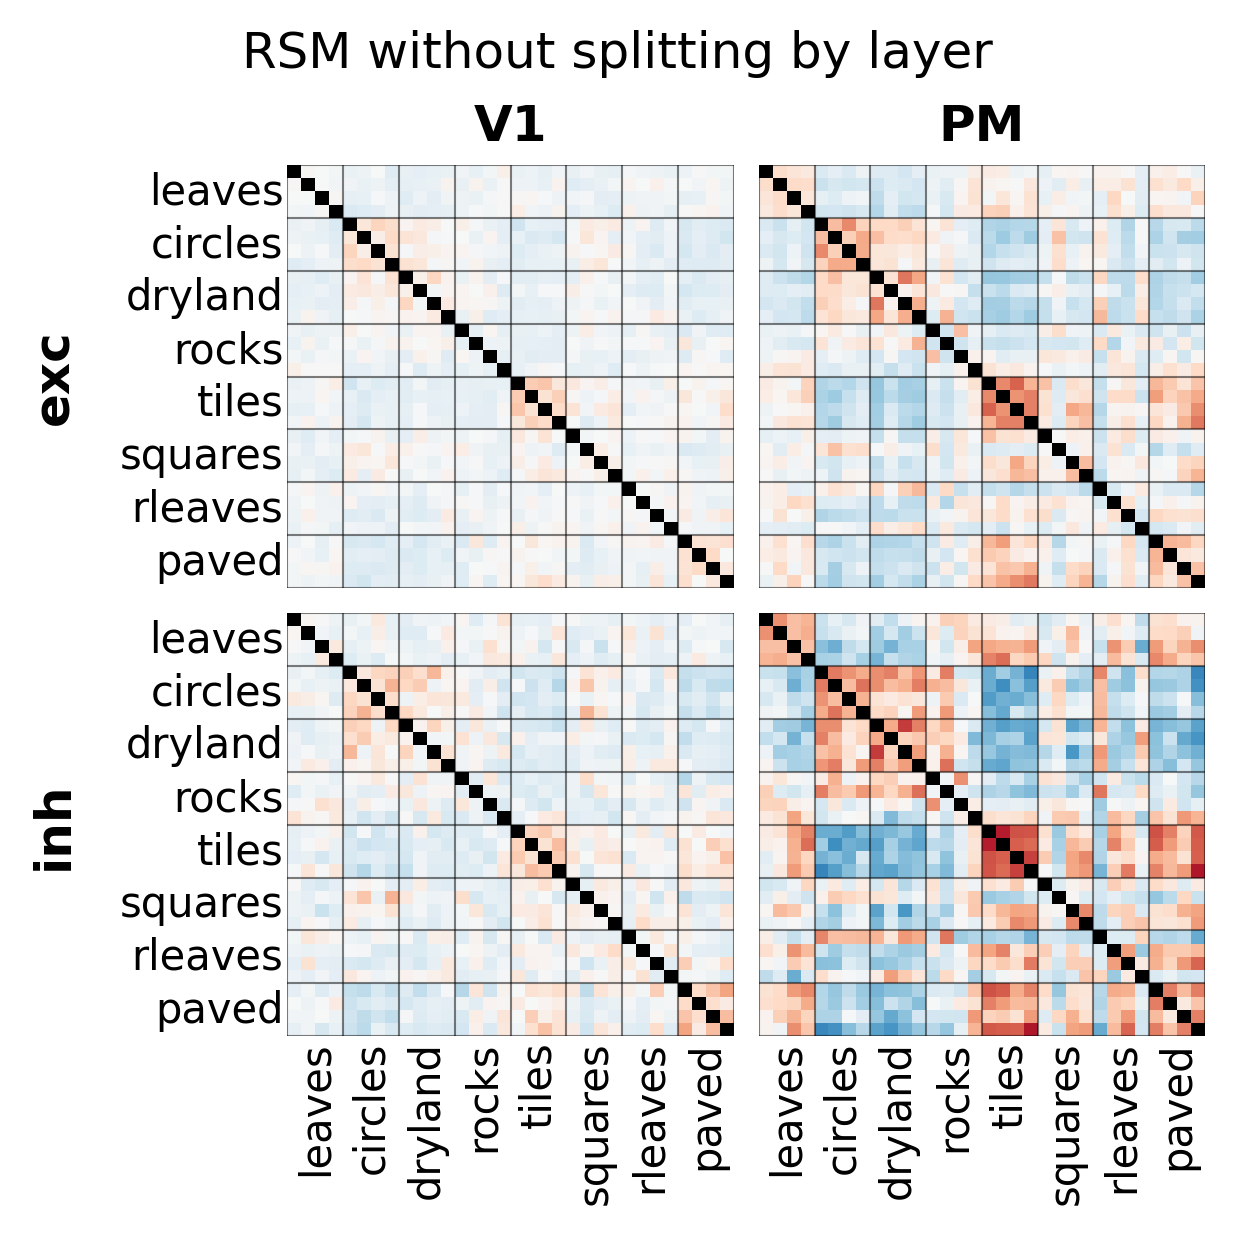

In [67]:
fig, ax = plt.subplots(2,2, figsize=(4,4), dpi=300, constrained_layout=True)
plot_representations(ax[0,0], avg_mice, area=0, layer=-1, ctype=0, cbar=False, noylabels=False, noxlabels=True, labelsize=10, Title="V1")
plot_representations(ax[0,1], avg_mice, area=1, layer=-1, ctype=0, cbar=False, noylabels=True, noxlabels=True, labelsize=10, Title="PM")
plot_representations(ax[1,0], avg_mice, area=0, layer=-1, ctype=1, cbar=False, noylabels=False, noxlabels=False, labelsize=10)
plot_representations(ax[1,1], avg_mice, area=1, layer=-1, ctype=1, cbar=False, noylabels=True, noxlabels=False, labelsize=10)
ax[0,0].set_ylabel("exc", fontsize=12, fontweight='bold', labelpad=10)
ax[1,0].set_ylabel("inh", fontsize=12, fontweight='bold', labelpad=10)
fig.suptitle("RSM without splitting by layer")

Sim vs Gcamp mice

In [56]:
g6mtx = np.load("C:\\Users\\labadmin\\Documents\\oneshot-neural\\results\\Gcamp6_rep_mtx_allareas_pctile.npy")
g8mtx = np.load("C:\\Users\\labadmin\\Documents\\oneshot-neural\\results\\Gcamp8_rep_mtx_allareas_pctile.npy")
all_mice = np.concatenate((g6mtx, g8mtx), axis=0)
avg_mice_gcamp = np.nanmean(all_mice, axis=0)

In [70]:
avg_mice_gcamp.shape

(10, 2, 32, 32)

Text(0.5, 1.0, 'Difference in RSM between VGAT-GCaMP and GCaMP6/8 (V1 layer 3)')

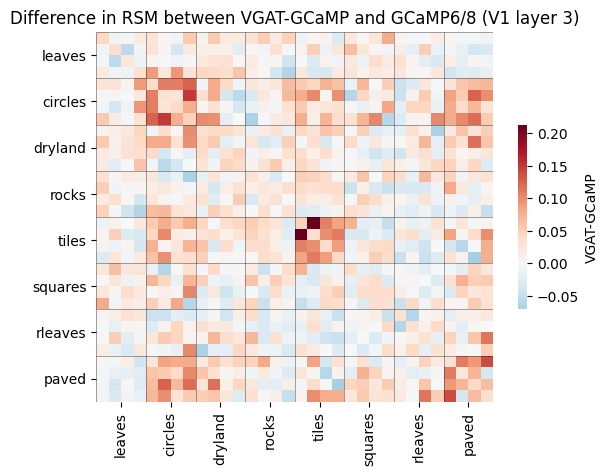

In [89]:
vmax = (np.abs(avg_mice[0,0,:,:])-np.abs(avg_mice_gcamp[0,1,:,:])).max()
vmin = (np.abs(avg_mice[0,0,:,:])-np.abs(avg_mice_gcamp[0,1,:,:])).min()
sns.heatmap(np.abs(avg_mice[0,0,:,:])-np.abs(avg_mice_gcamp[0,1,:,:]), cmap='RdBu_r', vmin=vmin, vmax=vmax, center=0, 
            xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5, "label": "VGAT-GCaMP"}, rasterized=True)
plt.vlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
plt.hlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
labels = ["leaves","circles","dryland","rocks","tiles","squares","rleaves","paved"]
plt.yticks(np.arange(2, 32, 4), labels);
plt.xticks(np.arange(2, 32, 4), labels, rotation=90);
plt.title("Difference in RSM between VGAT-GCaMP and GCaMP6/8 (V1 layer 3)")

In [94]:
rep_mtx[0, 0, :, :].shape

(2, 32, 32)

Text(0.5, 1.0, 'PM train/test matrix diff')

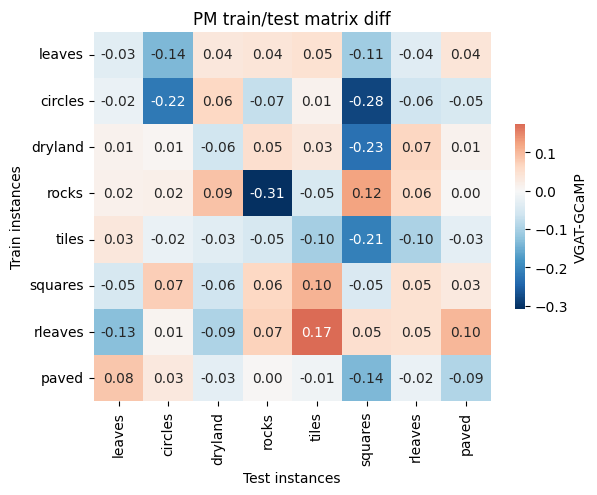

In [112]:
behav_matrix_vgat = invariance.reduce_to_behav(avg_mice[1, 0, :, :])
behav_matrix_gcamp = invariance.reduce_to_behav(avg_mice_gcamp[1, 0, :, :])
train_test_vgat = behav_matrix_vgat[::2, 1::2]
train_test_gcamp = behav_matrix_gcamp[::2, 1::2]
dff = np.abs(train_test_vgat) - np.abs(train_test_gcamp)
vmax = dff.max()
vmin = dff.min()
def make_behav_labels():
    categories = ["leaves","circles","dryland","rocks","tiles","squares","rleaves","paved"]
    behav_instances = []
    for cat in categories:
        if (cat == "rocks"):
            for i in [0,2]:
                behav_instances.append(cat + str(i))
        else:
            for i in range(2):
                behav_instances.append(cat + str(i))
    behav_instances = np.array(behav_instances)
    return categories
labels = make_behav_labels()
sns.heatmap(dff, cmap='RdBu_r', vmin=vmin, vmax=vmax, center=0, 
            xticklabels=labels, yticklabels=labels, 
            cbar_kws={"shrink": 0.5, "label": "VGAT-GCaMP"}, annot=True, fmt='.2f', rasterized=True)
plt.ylabel("Train instances")
plt.xlabel("Test instances")
plt.title("PM train/test matrix diff")

Text(0.5, 1.0, 'Difference in RSM between VGAT-GCaMP and GCaMP6/8 (PM layer 2)')

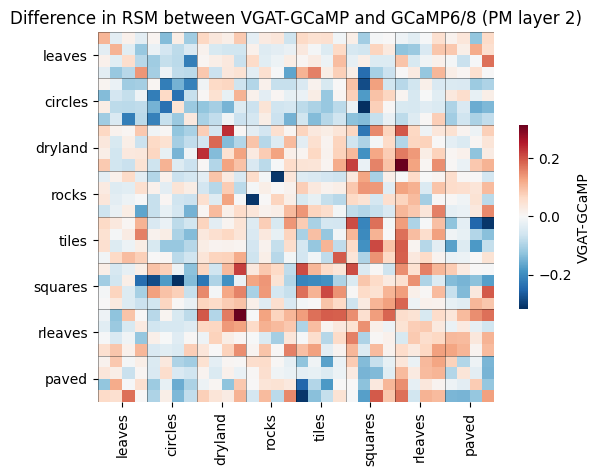

In [88]:
vmax = (np.abs(avg_mice[1,0,:,:])-np.abs(avg_mice_gcamp[1,0,:,:])).max()
vmin = (np.abs(avg_mice[1,0,:,:])-np.abs(avg_mice_gcamp[1,0,:,:])).min()
sns.heatmap(np.abs(avg_mice[1,0,:,:])-np.abs(avg_mice_gcamp[1,0,:,:]), cmap='RdBu_r', vmin=vmin, vmax=vmax, center=0, 
            xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5, "label": "VGAT-GCaMP"}, rasterized=True)
plt.vlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
plt.hlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
labels = ["leaves","circles","dryland","rocks","tiles","squares","rleaves","paved"]
plt.yticks(np.arange(2, 32, 4), labels);
plt.xticks(np.arange(2, 32, 4), labels, rotation=90);
plt.title("Difference in RSM between VGAT-GCaMP and GCaMP6/8 (PM layer 2)")

In [57]:
#set diags as nan to avoid correlation with itself
from scipy.stats import pearsonr
nareas, nlayers, _, _ = avg_mice_gcamp.shape
correlations = np.zeros((nareas, nlayers))
for area in range(nareas):
    for layer in range(nlayers):
        a = avg_mice_gcamp[area,layer]
        b = avg_mice[area,1]
        #take only the upper triangle of the matrices to avoid correlation with itself
        a = np.triu(a, k=1)
        b = np.triu(b, k=1)
        corr, _ = pearsonr(a.flatten(), b.flatten())
        correlations[area, layer] = corr

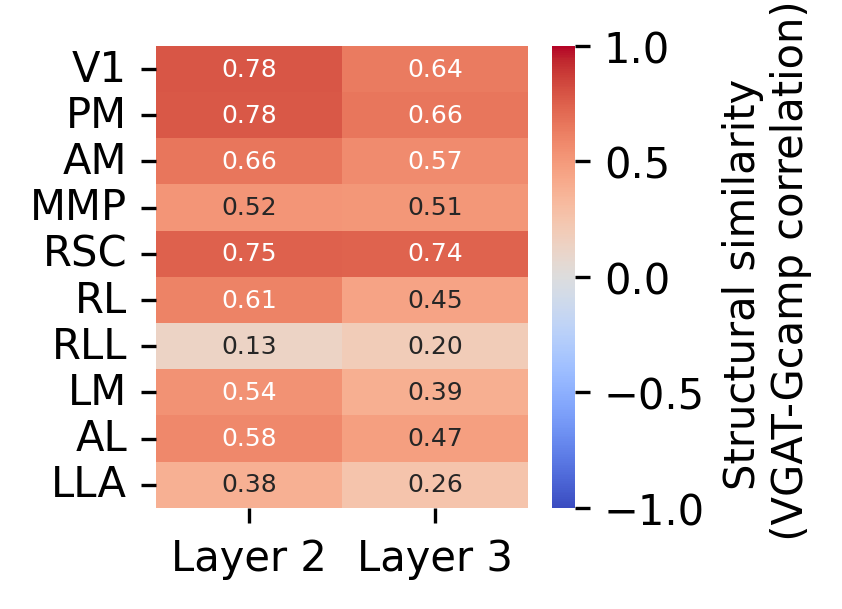

In [58]:
plt.figure(figsize=(2,2), dpi=300)
sns.heatmap(correlations, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 6},
            cbar_kws={'label': 'Structural similarity \n (VGAT-Gcamp correlation)'})

plt.yticks(np.arange(nareas)+.5, ['V1', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA'], fontsize=10, rotation=0);
plt.xticks(np.arange(nlayers)+.5, ['Layer 2', 'Layer 3'], fontsize=10, rotation=0);

In [59]:
df = get_pair_invariance_df(rep_mtx)
df_cleaned = df.groupby(["mouse", "area", "ctype"])["pair_invariance"].mean().reset_index()
custom_order = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
df_cleaned['area'] = pd.Categorical(df_cleaned['area'], categories=custom_order, ordered=True)
custom_order = ['exc', 'inh']
df_cleaned['ctype'] = pd.Categorical(df_cleaned['ctype'], categories=custom_order, ordered=True)

Text(0.5, 0, '')

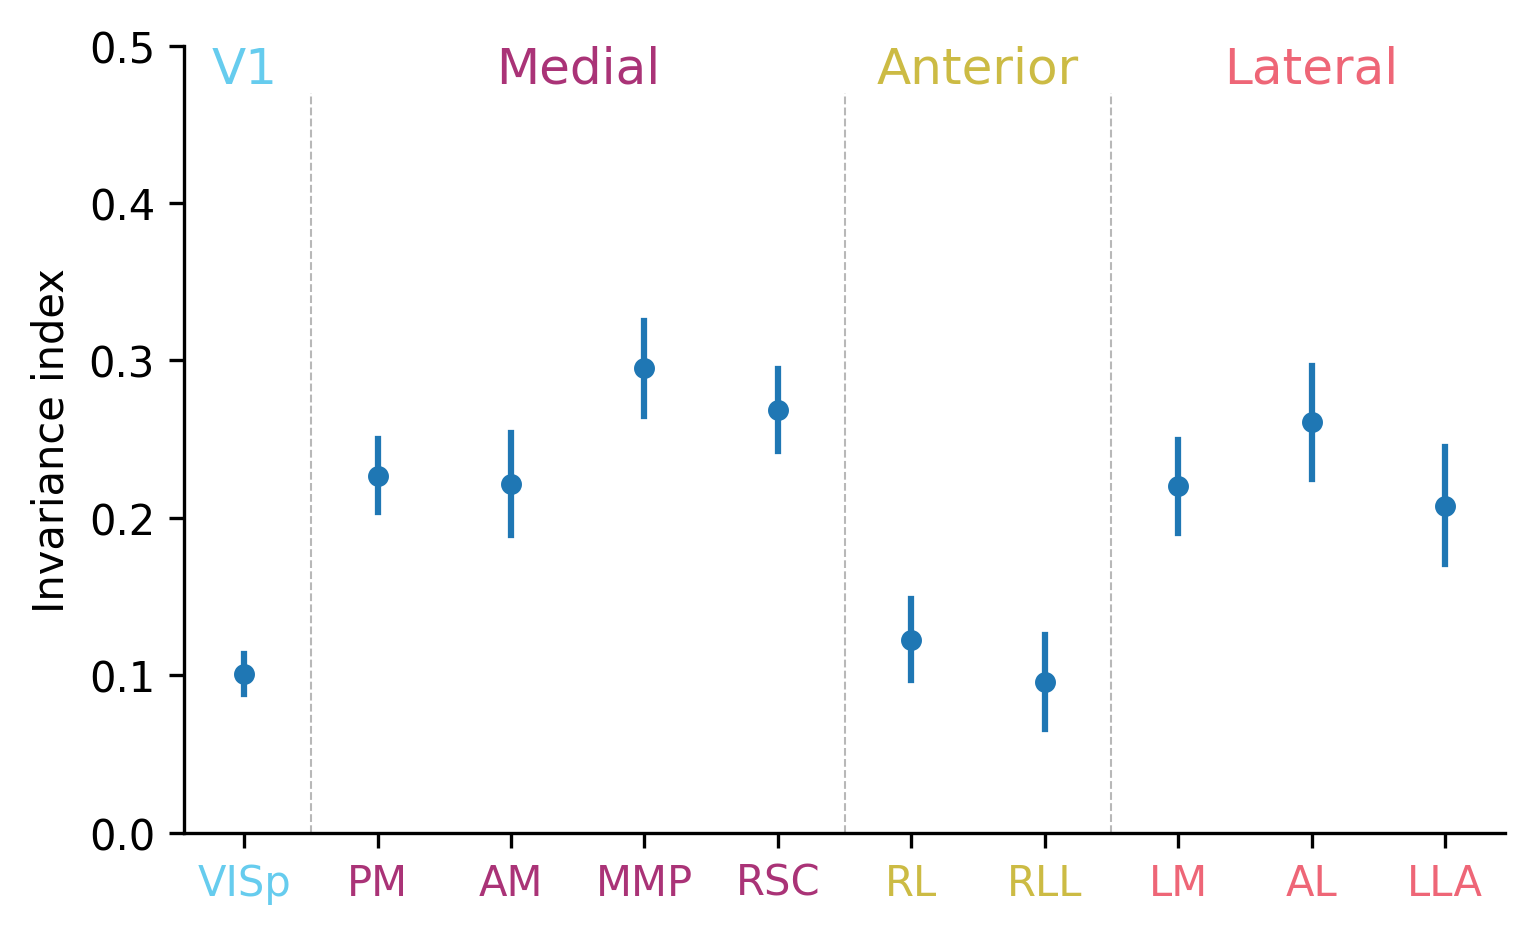

In [60]:
fig, ax = plt.subplots(1,1, figsize=(5,3), dpi=300, constrained_layout=True)
sns.pointplot(x="area", y="pair_invariance", data=df_cleaned.query("ctype == 'exc'"), 
            errorbar="se", linestyle='none', markers='o',
            markersize=3, err_kws={'linewidth': 1.5}, legend=False, ax=ax)
sns.despine()
ax.set_ylabel("Invariance index")
set_y = .45
ax.set_ylim(0, .5)
# lines 
coordinates = [.5, 4.5, 6.5]
for coord in coordinates:
    ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
    ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
    ax.vlines(coord, 0, set_y+.02, color = 'k', alpha = .1, linestyle = '--', linewidth=.5)
tcolors = ["#66CCEE", "#AA3377", "#AA3377", "#AA3377", "#AA3377", "#CCBB44", "#CCBB44", "#EE6677", "#EE6677", "#EE6677"]
labels_ = ['VISp', 'PM', 'AM', 'MMP', 'RSC', 'RL', 'RLL', 'LM', 'AL', 'LLA']
for tlabel, tcolor in zip(ax.get_xticklabels(), tcolors):
    tlabel.set_color(tcolor)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels_)
ax.xaxis.set_tick_params()
corrdinates = [0, 2.5, 5.5, 8]
texts = ['V1', 'Medial', 'Anterior', 'Lateral']
colors = ["#66CCEE", "#AA3377", "#CCBB44", "#EE6677"]
for i, coord in enumerate(corrdinates):
    ax.text(coord, set_y+.02, texts[i], ha='center', va='bottom', color=colors[i], fontsize=12)
ax.set_xlabel("")

# corr with behav

In [61]:
def get_DI_GI_df(avg_mice_rep_mtx, small_areas = True):
    Gcamp6_df_pair_DI = pd.DataFrame()
    if small_areas:
        areas = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    else:
        areas = ['V1', 'medial', 'lateral','anterior']
    ctype = ['exc', 'inh']
    cat = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved'] 
    for i_a, area in enumerate(areas):
        for ic, ct in enumerate(ctype):
            df = pd.DataFrame()
            matrix = avg_mice_rep_mtx[i_a, ic, :, :] # gets the representational sim matrix for the area and layer
            behav_m = invariance.reduce_to_behav(matrix) # reduces the representational sim matrix to the behavioral instances
            only_train = behav_m[::2,::2] # gets the training instances
            a, b = np.triu_indices(8,1) # gets the upper triangle indices
            positive_cat = []
            negative_cat = []
            di_index = []
            for i in zip(a,b): #loops over all the posible pairs
                positive_cat.append(cat[i[0]])
                negative_cat.append(cat[i[1]])
                a_ab = only_train[i[0],i[0]] - only_train[i[0],i[1]] #x_11 - x_12
                b_ab = only_train[i[1],i[1]] - only_train[i[0],i[1]] #x_22 - x_12
                di_avg = np.mean([a_ab, b_ab]) # avg
                di_index.append(di_avg)
            df["positive_category"] = np.array(positive_cat)
            df["negative_category"] = np.array(negative_cat)
            df["DI_brain"] = np.array(di_index)
            df["area"] = area
            df["ctype"] = ct
            Gcamp6_df_pair_DI = pd.concat([Gcamp6_df_pair_DI, df])
    Gcamp6_df_pair_DI.reset_index(inplace=True, drop=True)
    Gcamp6_df_pair_GI = pd.DataFrame()
    for i_a, area in enumerate(areas):
        for ic, ct in enumerate(ctype):
            df = pd.DataFrame()
            matrix = avg_mice_rep_mtx[i_a, ic, :, :] # gets the representational sim matrix for the area and layer
            behav_m = invariance.reduce_to_behav(matrix) # reduces the representational sim matrix to the behavioral instances
            cross = behav_m[::2,1::2] # gets the crosstab
            a, b = np.triu_indices(8,1) # gets the upper triangle indices
            positive_cat = []
            negative_cat = []
            gi_index = []
            for i in zip(a,b): #loops over all the posible pairs
                positive_cat.append(cat[i[0]])
                negative_cat.append(cat[i[1]])
                ap_a = cross[i[0],i[0]] 
                ap_b = cross[i[1],i[0]] 
                bp_a = cross[i[0],i[1]]
                bp_b = cross[i[1],i[1]]
                gi = ((ap_a - ap_b) + (bp_b - bp_a))/2
                gi_index.append(gi)
            df["positive_category"] = np.array(positive_cat)
            df["negative_category"] = np.array(negative_cat)
            df["GI_brain"] = np.array(gi_index)
            df["area"] = area
            df["ctype"] = ct
            Gcamp6_df_pair_GI = pd.concat([Gcamp6_df_pair_GI, df])
    Gcamp6_df_pair_GI.reset_index(inplace=True, drop=True)
    behav_new_metrics = pd.merge(Gcamp6_df_pair_DI, Gcamp6_df_pair_GI, on=['positive_category', 'negative_category', 'area', 'ctype'])
    behav_new_metrics["category_pair"] = behav_new_metrics["positive_category"].str.lower() + "/" + behav_new_metrics["negative_category"].str.lower()
    return behav_new_metrics

def get_DI_GI_behav(first100df):
    df_c = first100df.copy()
    df_c['positive_category'] = first100df['negative_category']
    df_c['negative_category'] = first100df['positive_category']
    crosstab = pd.concat([first100df, df_c])
    crosstab_GI = crosstab[['positive_category', 'negative_category', 'GI_behav']]
    crosstab_GI = pd.crosstab(crosstab_GI['positive_category'], crosstab_GI['negative_category'], values = crosstab_GI['GI_behav'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_GI = crosstab_GI.reindex(index = index_order, columns=index_order)
    crosstab_DI = crosstab[['positive_category', 'negative_category', 'DI_behav']]
    crosstab_DI = pd.crosstab(crosstab_DI['positive_category'], crosstab_DI['negative_category'], values = crosstab_DI['DI_behav'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_DI = crosstab_DI.reindex(index = index_order, columns=index_order)
    a,b = np.triu_indices(8, k=1)
    bhv_gi_num_ordered  = []
    bhv_di_ordered = []
    for i in zip(a,b):
        bhv_gi_num_ordered.append(crosstab_ordered_GI.iloc[i[0],i[1]])
        bhv_di_ordered.append(crosstab_ordered_DI.iloc[i[0],i[1]])
    bhv_gi_num_ordered = np.array(bhv_gi_num_ordered)
    bhv_di_ordered = np.array(bhv_di_ordered)
    inv_new_metrics = pd.read_csv(r"C:\Users\labadmin\Documents\oneshot-neural\results\gcamp6_behav_new_metrics.csv", index_col=0)
    cat_pairs = inv_new_metrics.query("area == 'V1' & layer == 1")["category_pair"].values
    DI_metrics_behav = pd.DataFrame({'Category_pair': cat_pairs, 'GI_behav': bhv_gi_num_ordered, 'DI_behav': bhv_di_ordered})
    return DI_metrics_behav
from scipy import stats
def perm_test(behav_df, brain_df, area, ctype, metric='GI_norm', n_shuffles=10000, plot=None):
    metric_brain = f"{metric}_brain"
    metric_behav = f"{metric}_behav"
    # add indexes to behav_df for permutation BEHAVIOR
    positive_cat = behav_df["Category_pair"].str.split("/").str[0]
    negative_cat = behav_df["Category_pair"].str.split("/").str[1]
    behav_df = behav_df.assign(positive_cat=positive_cat, negative_cat=negative_cat)
    cat_map = {'leaves': 0, 'circles': 1, 'dryland': 2, 'rocks': 3, 'tiles': 4, 'squares': 5, 'rleaves': 6, 'paved': 7} # this df has them lowecase
    behav_df = behav_df.assign(positive_cat_num=behav_df['positive_cat'].map(cat_map), negative_cat_num=behav_df['negative_cat'].map(cat_map))
    # BRAIN
    #subsample the area / layer 
    queried = brain_df.query(f"area=='{area}' & ctype=='{ctype}'").copy()
    queried = queried.assign(positive_category=queried["positive_category"].str.lower(), negative_category=queried["negative_category"].str.lower())
    # map the 'category' column to the new names using the cat_map
    queried.loc[:, "pos_idx"] = queried["positive_category"].map(cat_map)
    queried.loc[:, "neg_idx"] = queried["negative_category"].map(cat_map)
    brain_vals = queried[metric_brain].values
    pos_map = queried["pos_idx"].astype(int).values
    neg_map = queried["neg_idx"].astype(int).values

    #lets create the matrix that maps the brain values to the behav values
    n_cats = 8
    behav_mat = np.zeros((n_cats, n_cats))
    for i, row in behav_df.iterrows():
        p, n = int(row['positive_cat_num']), int(row['negative_cat_num'])
        val = row[metric_behav]
        behav_mat[p, n] = val
        behav_mat[n, p] = val
    #here I get the real correlation
    real_behav_vec = behav_df[metric_behav].values
    observed_r, _  = stats.pearsonr(brain_vals, real_behav_vec)
    #print(f"Observed correlation: {observed_r:.4f}")
    #shuffle the behav matrix and get the null distribution of correlations
    null_rs = []
    n_shuffles = 10000
    rng = np.random.default_rng(42)
    for _ in range(n_shuffles):
        perm = rng.permutation(n_cats)
        shuffled_mat = behav_mat[perm, :][:, perm] #here im doing the swap
        shuffled_behav_vec = shuffled_mat[pos_map, neg_map]
        r_null, _ = stats.pearsonr(brain_vals, shuffled_behav_vec)
        null_rs.append(r_null)
    null_rs = np.array(null_rs)
    p_perm = np.sum(null_rs >= observed_r) / n_shuffles
    #print(f"permutation p-value: {p_perm:.4f}")

    if plot is not None:
        sns.histplot(null_rs, kde=True, ax=plot)
        plot.axvline(observed_r, color='red', linestyle='--', label=f'Observed r={observed_r:.4f}')
        plot.text(observed_r+0.1, plot.get_ylim()[1]*0.9, f'p={p_perm:.4f}', color='red', ha='center')
        plot.set_title(f"{area} ctype {ctype}")
        sig = significance(p_perm)
        plot.text(0.05, 0.95, f"obs r={observed_r:.4f}{sig}", transform=plot.transAxes, fontsize=8, fontweight='bold', va='top')
    return observed_r, p_perm


def regplot_perm(DI_metrics, DI_metrics_behav, metric, area, ctype, ax, norm=False, sig_coor=(.6,.4), n_shuffles=10000):
    query = f"ctype == '{ctype}' & area == '{area}'"
    if (norm == True) & (metric=='GI'):
        brain_pair_inv = DI_metrics.query(query)[f"{metric}_norm_brain"].values
        behav_inv =  DI_metrics_behav[f"{metric}_norm_behav"].values
        corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='GI_norm', n_shuffles=10000)    
    else:
        brain_pair_inv = DI_metrics.query(query)[f"{metric}_brain"].values
        behav_inv =  DI_metrics_behav[f"{metric}_behav"].values
        corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='DI', n_shuffles=10000)    
    brain_pair_inv = brain_pair_inv[~np.isnan(behav_inv)]
    behav_inv = behav_inv[~np.isnan(behav_inv)]
    sig = significance(pval)
    #if pval > .05:
    #    sns.regplot(x=behav_inv, y=brain_pair_inv, ci=95, line_kws=dict(color="r"), scatter_kws=dict(color = '#020508', s=10), fit_reg=False, ax=ax)
    #else:
    sns.regplot(x=behav_inv, y=brain_pair_inv, ci=95, line_kws=dict(color="r"), scatter_kws=dict(color = '#020508', s=10), fit_reg=True, ax=ax)
    ax.text(sig_coor[0],sig_coor[1],f" r = {corr:.2f}{sig}", color='r', fontsize=10, transform=ax.transAxes)
    ax.set_xticks([0,.5,1])
    return corr, pval, sig

from statsmodels.stats.multitest import multipletests
def get_pvals_corrected_perm(DI_metrics_behav, DI_metrics, areas, dset="test", method='fdr_bh'):
    corrs = np.full((len(areas), 2), np.nan)
    pvals = np.full((len(areas), 2), np.nan)
    for i, area in enumerate(areas):
        for ic, ctype in enumerate(['exc', 'inh']):
            if dset=='test':
                corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='GI_norm', n_shuffles=10000)
            else:
                corr, pval = perm_test(DI_metrics_behav, DI_metrics, area=area, ctype=ctype, metric='DI', n_shuffles=10000)
            corrs[i, ic] = corr
            pvals[i, ic] = pval           
    rejected, pvals_corrected, _, _ = multipletests(pvals.flatten(), alpha=0.05, method=method)
    return corrs, pvals, pvals_corrected.reshape(-1, 2)

In [62]:
first100df = pd.read_csv(r"C:\Users\labadmin\Documents\GeneralizationPaper\Figure1\all_sessions_150_250_first100.csv", index_col=0)
first100df.rename(columns={"DI":"DI_behav","GI_num":"GI_behav"}, inplace=True)
first100df = first100df.assign(GI_norm_behav = first100df['GI_behav']/first100df['DI_behav'])
DI_metrics_behav = get_DI_GI_behav(first100df)
DI_metrics_behav = DI_metrics_behav.assign(GI_norm_behav = DI_metrics_behav['GI_behav']/DI_metrics_behav['DI_behav'])

In [63]:
di_vg = get_DI_GI_df(avg_mice, small_areas=True)
di_vg = di_vg.assign(GI_norm_brain = di_vg['GI_brain']/di_vg['DI_brain'])

Text(0.5, 0.98, 'Exc')

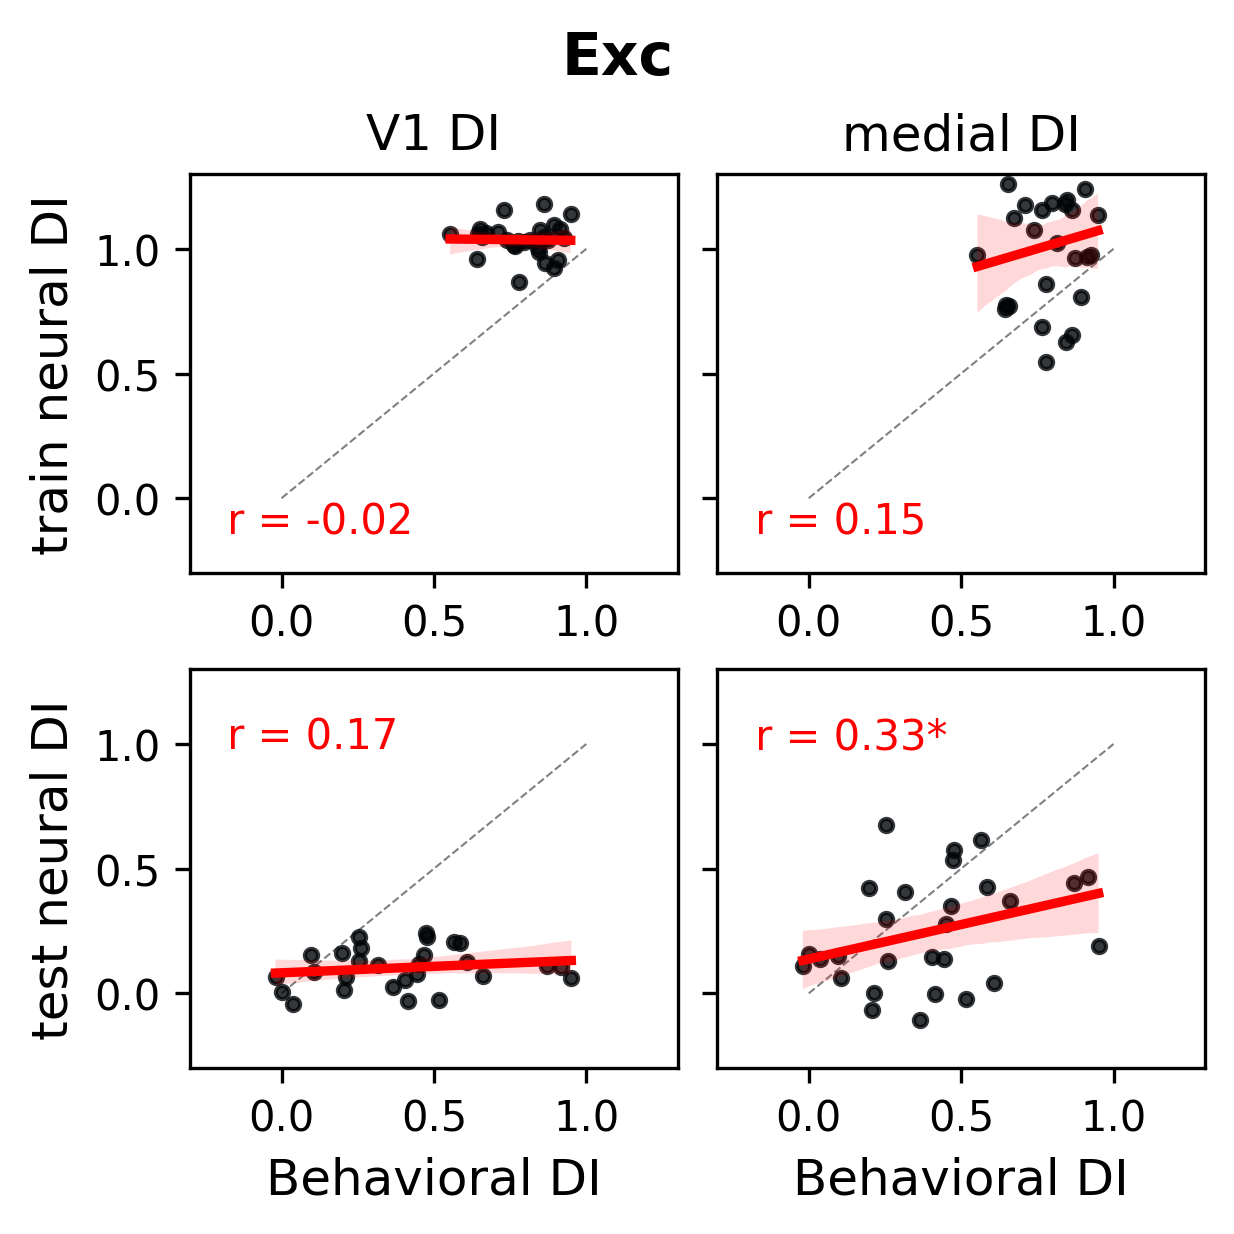

In [114]:
fig, reg_ax_g6 = plt.subplots(2,2, figsize=(4,4), dpi=300, sharey=True, constrained_layout=True)
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "exc", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISal", "exc", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "exc", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISal", "exc", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,1])
for ax in reg_ax_g6.flatten():
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
reg_ax_g6[1,0].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[1,1].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[0,0].set_ylabel("train neural DI", fontsize=12)
reg_ax_g6[1,0].set_ylabel("test neural DI", fontsize=12)
reg_ax_g6[0,0].set_title("V1 DI", fontsize=12)
reg_ax_g6[0,1].set_title("medial DI", fontsize=12)
fig.suptitle("Exc", fontsize=14, fontweight='bold')

In [101]:
def DI_matrix(df_only100, ax):
    df_c = df_only100.copy()
    df_c['positive_category'] = df_only100['negative_category']
    df_c['negative_category'] = df_only100['positive_category']
    crosstab = pd.concat([df_only100, df_c])
    crosstab_GI = crosstab[['positive_category', 'negative_category', 'GI_norm_brain']]
    crosstab_GI = pd.crosstab(crosstab_GI['positive_category'], crosstab_GI['negative_category'], values = crosstab_GI['GI_norm_brain'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_GI = crosstab_GI.reindex(index = index_order, columns=index_order)
    crosstab_DI = crosstab[['positive_category', 'negative_category', 'DI_brain']]
    crosstab_DI = pd.crosstab(crosstab_DI['positive_category'], crosstab_DI['negative_category'], values = crosstab_DI['DI_brain'], aggfunc='mean')
    index_order = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved']
    crosstab_ordered_DI = crosstab_DI.reindex(index = index_order, columns=index_order)
    upper_mask = np.triu(np.ones_like(crosstab_ordered_GI, dtype=bool))
    g = sns.heatmap(crosstab_ordered_GI, cmap='RdBu_r', annot=True, fmt='.2f', cbar=False, 
                annot_kws={"size": 10}, vmax=.75, vmin=-.75, cbar_kws={'label': 'Neural discrimination index', 
                'orientation': 'horizontal', 'pad': 0.25, 'shrink':.8},  mask=~upper_mask, ax = ax)

    sns.heatmap(crosstab_ordered_DI, cmap='RdBu_r', annot=True, fmt='.2f', cbar=False, vmax=.75, vmin=-.75, mask=upper_mask, annot_kws={"size": 10}, ax=ax)
    ax.plot([-1.5, len(crosstab_ordered_GI)], [-1.5, len(crosstab_ordered_GI)], color='k', linestyle='--', linewidth=1, clip_on=False)
    #remove tick marks
    ax.tick_params(axis='both', which='both', length=0, labelsize=10, pad=5)
    #increase the space of the tick labels and the plot
    #ax.text(.5, 0.2, "Test", size=10, rotation=-40, ha='center', va='center', clip_on=False)
    #ax.text(0.25,.65, "Train", size=10, rotation=-40, ha='center', va='center', clip_on=False)
    anchor = -1.9
    ax.text(anchor + 0.4, anchor + 1.1, "Test", size=14,
            rotation=-45, ha='left', va='bottom', clip_on=False)
    
    ax.text(anchor - 0.2, anchor + 2, "Train", size=14,
            rotation=-45, ha='left', va='bottom', clip_on=False)
    ax.set_xlabel("")
    ax.set_ylabel("");
    cb = g.collections[0].colorbar
    return cb

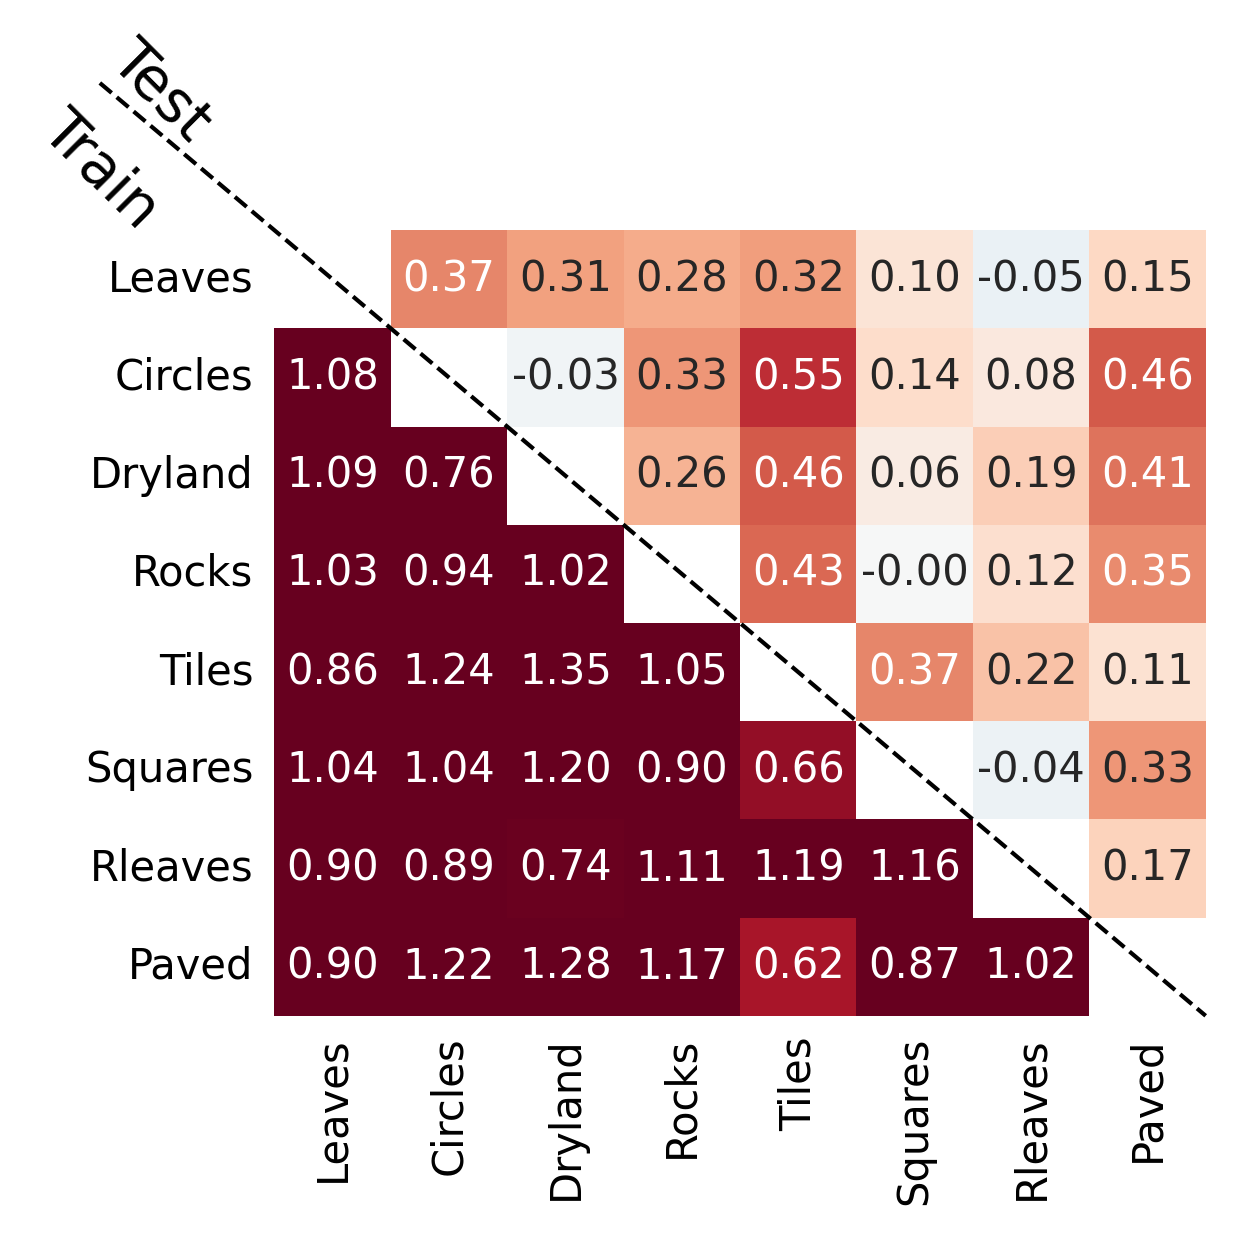

In [108]:
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300, constrained_layout=True)
cb = DI_matrix(di_vg.query("area == 'VISpm' & ctype == 'exc'"), ax)

Text(0.5, 0.98, 'inh')

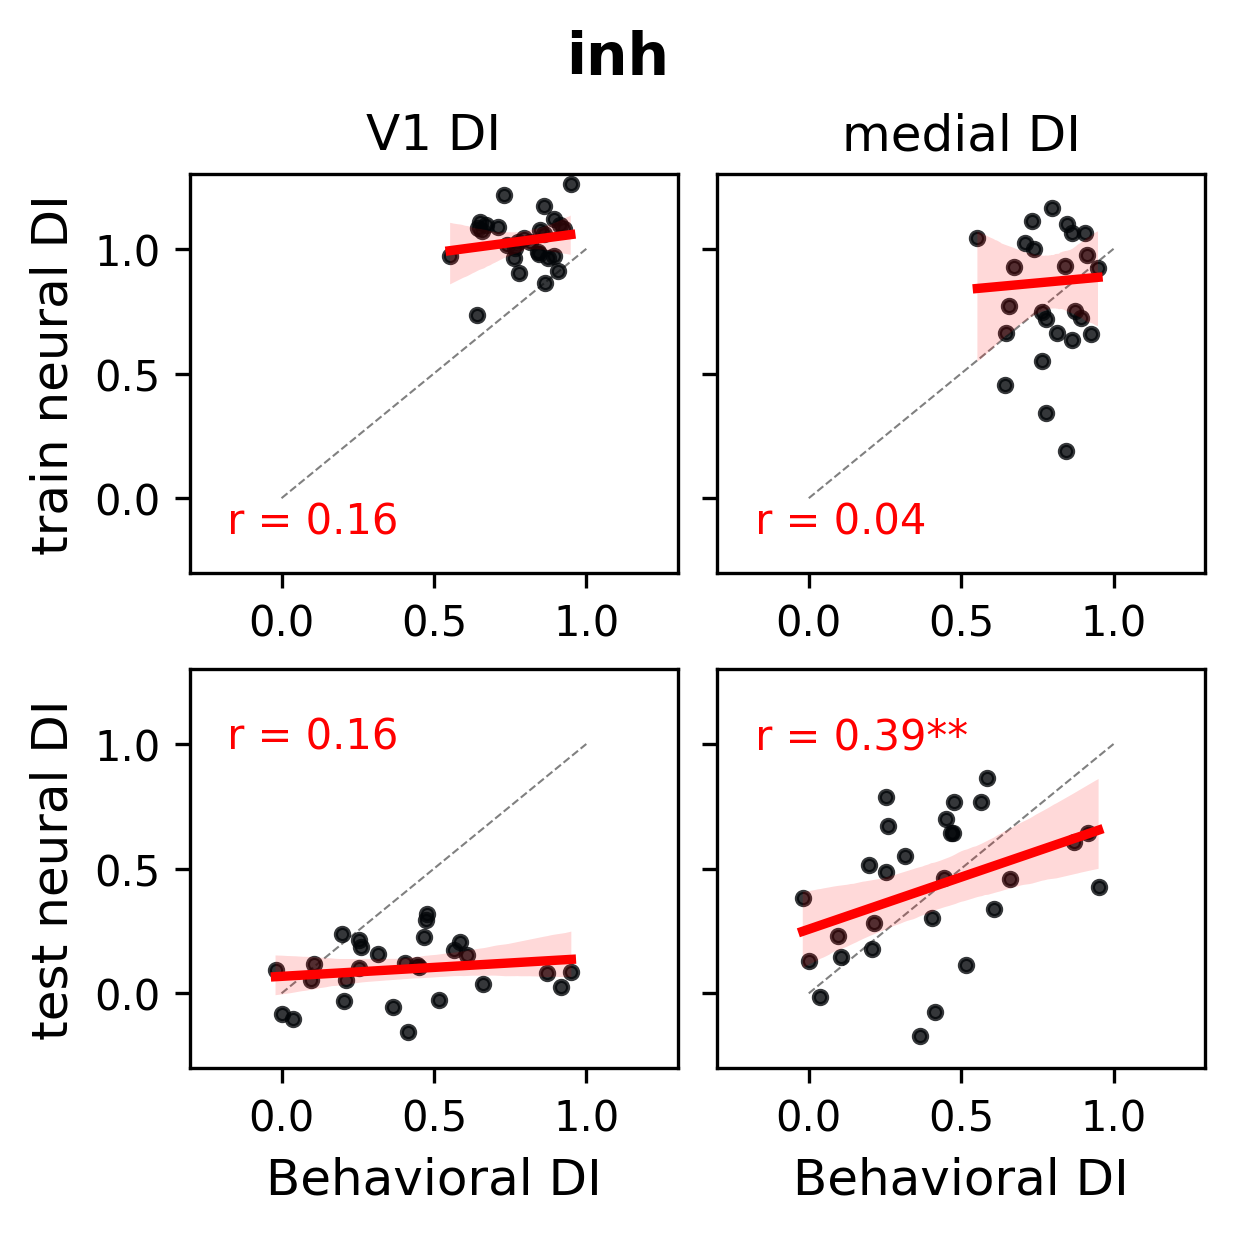

In [65]:
fig, reg_ax_g6 = plt.subplots(2,2, figsize=(4,4), dpi=300, sharey=True, constrained_layout=True)
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISp", "inh", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,0])
regplot_perm(di_vg, DI_metrics_behav, "DI", "VISpm", "inh", sig_coor=(.05,.1), norm=True, ax=reg_ax_g6[0,1])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISp", "inh", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,0])
regplot_perm(di_vg, DI_metrics_behav, "GI", "VISpm", "inh", sig_coor=(.05,.8), norm=True, ax=reg_ax_g6[1,1])
for ax in reg_ax_g6.flatten():
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-0.3, 1.3)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=.5, zorder=0)
reg_ax_g6[1,0].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[1,1].set_xlabel("Behavioral DI", fontsize=12)
reg_ax_g6[0,0].set_ylabel("train neural DI", fontsize=12)
reg_ax_g6[1,0].set_ylabel("test neural DI", fontsize=12)
reg_ax_g6[0,0].set_title("V1 DI", fontsize=12)
reg_ax_g6[0,1].set_title("medial DI", fontsize=12)
fig.suptitle("inh", fontsize=14, fontweight='bold')